<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>
<h1><left><font size=5>Project 1 - Beacon Community Capital: Loan Application Sorter</font></left></h1>

# **Business Overview**

Beacon Community Capital is a Treasury-certified Community Development Financial Institution (a **CDFI**) based in Columbus, Ohio.

Its mission is to lend small personal and small-business loans to the people big banks turn away: borrowers with a thin credit history, or a past stumble that dented their score but who are reliable today. A single mother rebuilding after a medical bankruptcy. A food-truck owner whose income is real but irregular. These are Beacon's customers.

Today, every single application is read and decided **by hand** by a team of five loan officers.

The mission is working, and that is the problem. As word has spread, applications have climbed from about **500 a month to roughly 1,800 a month**. The five officers cannot keep up. A decision that should take a day now takes **three to four days**, and good applicants are giving up and walking away while they wait.

# **The Challenge**

Two things are breaking at once: speed and consistency.

**Speed.** Five people reading 1,800 files a month by hand cannot move fast. The backlog grows every week.

**Consistency.** A recent internal review pulled a stack of past files and had a second officer re-decide them blind. The result was uncomfortable: about **1 in 5 files** would have been decided differently by the second officer. Same application, same numbers, different answer, depending only on who happened to pick it up.

The team once tried the obvious shortcut: a flat rule that approves anyone with a **FICO score of 660 or higher** and rejects everyone else. It failed, and it failed in the worst possible way. That rule rejected exactly the borrowers Beacon exists to serve: the self-employed applicant with a modest score but strong savings and a steady income. A blunt score cut-off cannot see the whole person.

So Beacon needs something **faster than three days** and **more consistent than five people deciding by hand**, without going back to a blunt rule that turns away its own customers.

# **Objective**

You are going to build a **first-pass sorter** for incoming applications.

For each application, the sorter reads the whole file and returns one of two answers, **approve** or **reject**, together with a **confidence level**: how sure it is, expressed as an approval probability between 0 and 1.

The confidence level decides what happens next:

| Confidence (approval probability) | What happens |
|---|---|
| **Above 0.80** | Clears automatically as an **approve** |
| **Below 0.20** | Clears automatically as a **reject** |
| **Between 0.20 and 0.80** | **Flagged to a human officer** to decide |

The two easy piles clear instantly, so the five officers spend their time only on the genuinely borderline files. These cut-offs are set by the business, not by the model.

**In scope:** a trained, evaluated model plus this decision rule.
**Out of scope:** plugging it into Beacon's live systems. That is a later project.

# **The One Thing You Must Never Forget**

Read this slowly, because it changes how you think about everything below.

The model learns from Beacon's **past decisions**. It studies applications that officers already approved or rejected, and it learns to **copy that pattern**. That single fact has two heavy consequences:

**1. The model copies past decisions. It does not predict who will repay.** It is not a crystal ball for default risk. It is a mirror of how officers have decided before. So if past officers were ever unfair, even by accident, the model will quietly learn that unfairness and repeat it at scale, 1,800 times a month. This is exactly why the middle confidence band exists: a **human officer must own every rejection.**

**2. Fair-lending law (ECOA) applies.** The model must never use race, age, or address. And you must stay alert to ordinary-looking columns that could secretly stand in for those things.

Keep this in the back of your mind through the whole build. You are automating a fair-lending decision. Fairness is the **first** question here, not a footnote.

# **Your Build, in Four Stages**

You will build this like a story, and each chapter sets up the next:

1. **Explore and Clean** - meet the data, see what is wrong with it, and fix it. You cannot trust a model built on messy data.
2. **Business Insights** - draw graphs and pull out plain facts, so you actually understand who gets approved and why. This is also where you answer the fairness questions.
3. **Model Training** - train one logistic regression model to copy the officers' good decisions.
4. **Evaluation** - measure it with one honest number, accuracy, prove it beats the old flat rule, and see how many files it could clear without a human.

Run the notebook top to bottom. Every stage depends on the one before it.

# **How You Will Work: AI-Assisted Coding**

You will **not** be handed the code, and you will **not** be handed ready-made prompts. Writing the right prompt is the whole skill this project is teaching, and your prompt trail is what we grade most heavily.

For each code step you will see three things:
1. **A short explanation** in a markdown cell, telling you *what* the step must do and *why* it comes now.
2. **A code cell with `##` instructions** describing what to build and what to ask Codex for, with a few blanks (`______`) to show you the structure. This is your starting point, not the answer.
3. **An "Expected result"** telling you the number or picture you should get, so you can check your own work.

**Your job at every code step:**
- Read the explanation and the `##` instructions in the cell.
- **Write your own clear prompt to Codex** (in VS Code) asking it to produce that piece of code.
- Paste Codex's code into the cell, replacing the `______` blanks, and run it.
- Check your output against the **Expected result**. If it is wrong, fix your prompt and try again, that back-and-forth is exactly what earns marks.

**Three habits that protect your Codex credits. Follow them every single time:**
- **Never paste the full CSV into Codex.** It is 232 rows and will burn your credits fast. Describe the columns instead, the instructions already name them for you.
- If you ever must show Codex real data, **paste at most about 20 rows**, never the whole file.
- **Reuse what you already built.** Do not reload or re-clean data you cleaned a few cells ago. Each step builds on the last.

**What you submit:** run the finished notebook top to bottom, export it to a single **HTML file**, and submit that, along with your **full Codex prompt trail** (every prompt you sent, starting with your Stage 0 planning prompt).

# **Stage 0 - Give Codex the Plan (Do This First)**

Good AI-assisted work starts before any code. First you tell your AI partner the **whole story**, so every later prompt lands in context instead of arriving cold.

Your first task is to write a **planning prompt**: a single message to Codex that hands over the full project context (the business, the data columns, the fairness constraint, and the four-stage plan) and asks it for a step-by-step build plan, **without writing any code yet**.

Everything you need is on this page above: the business overview, the objective, the fairness rule, the four stages, and the column list you will meet in Stage 1. Put those into your own words in the prompt.

**This planning prompt is the first and most important entry in your prompt trail.** Write it, send it to Codex, read the plan it gives back, and check it matches the four stages. Then move on to Setup below and build that plan stage by stage.

*(Tip: end your planning prompt with a guardrail line telling Codex never to ask you to paste the full CSV, only to work from the column descriptions.)*

# **Setup - Load the Tools**

Every project starts by loading its tools. **This one is done for you**, run the two cells below as they are. We use **pandas** for the data table, **matplotlib** and **seaborn** for the graphs, and a few pieces of **scikit-learn** to build and check the model.

In [ ]:
# If any of these libraries are missing in your environment, uncomment the line below and run it once.
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Charts
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split   # splits data into train and test sets
from sklearn.linear_model import LogisticRegression    # the model we will train
from sklearn.metrics import accuracy_score             # measures how often the model is right

# Make the charts look clean and show them inside the notebook
sns.set_style("whitegrid")
%matplotlib inline

# **Stage 1 - Explore and Clean the Data**

Here is the golden rule of every data project: **look before you leap.** A model trained on messy data gives confident, messy answers, and in lending that means unfair decisions. So before we build anything, we meet the data and repair it.

The dataset is a single file, `loan_applications.csv`. Each row is one loan application. Here is what every column means:

| Column | What it means |
|---|---|
| `applicant_id` | Unique ID for the applicant (e.g. BCC-1066) |
| `fico_score` | Credit score, roughly 300 to 850 |
| `annual_income` | Yearly income, in dollars |
| `loan_amount` | Amount requested, in dollars |
| `loan_term_months` | Months to repay |
| `employment_status` | Salaried or Self-employed |
| `years_employed` | Years in current employment |
| `savings_balance` | Money in savings, in dollars |
| `approved` | The past decision: Approved or Rejected (**this is what the model learns to copy**) |

### Step 1.1 - Load the data and check its size

First we load the file into a table (a pandas DataFrame) and check how big it is.

**Expected result:** 232 rows and 9 columns.

In [4]:
## TASK: Load the data.
## Write a prompt asking Codex to load the file 'loan_applications.csv' into a pandas
## DataFrame called df, and then print the number of rows and columns using df.shape.
## Tell Codex NOT to print the whole table.
## Paste Codex's code below (replacing the blanks) and run it.

df = pd.read_csv("loan_applications.csv")
print("Dataset shape (rows, columns):", df.shape)

Dataset shape (rows, columns): (232, 9)


### Step 1.2 - Look at the first few rows

Numbers in a shape tell us how big the table is. Now we actually look at it, to see what real rows look like.

In [5]:
## TASK: Look at the first few rows.
## Prompt Codex for one line of code that displays the first 5 rows of df.

df.head()

,applicant_id,fico_score,annual_income,loan_amount,loan_term_months,employment_status,years_employed,savings_balance,approved
0,BCC-1219,NaN,69100,12000,48,Self-employed,20,19200,Approved
1,BCC-1066,646.0,64900,19500,24,Salaried,12,21100,Approved
2,BCC-1009,610.0,50500,9200,36,Self-employed,12,7300,Approved
3,BCC-1170,624.0,20000,10800,12,Salaried,11,8700,Approved
4,BCC-1015,610.0,41000,10400,36,Salaried,17,3800,Approved


### Step 1.3 - Check column types and missing values

This one command is the most useful in all of data cleaning. It tells us, for every column, its **data type** and how many values are filled in. We are hunting for two red flags: **money columns stored as text**, and **columns with missing values**.

**Expected result:** the three money columns show up as text (object), and fico_score has fewer filled-in values than the rest.

In [9]:
## TASK: Check column types and missing values.
## Prompt Codex for one line that prints a concise summary of df showing each column,
## its data type, and how many non-null (filled-in) values it has.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   applicant_id       232 non-null    str    
 1   fico_score         222 non-null    float64
 2   annual_income      232 non-null    str    
 3   loan_amount        232 non-null    str    
 4   loan_term_months   232 non-null    int64  
 5   employment_status  232 non-null    str    
 6   years_employed     232 non-null    int64  
 7   savings_balance    232 non-null    str    
 8   approved           232 non-null    str    
dtypes: float64(1), int64(2), str(6)
memory usage: 16.4 KB


### Step 1.4 - Summary statistics

Now we look at the range of each number column: its smallest value, largest value, and average. This is the fastest way to catch **impossible values**, like a negative income or a 999-month loan term.

**Expected result:** you will spot a max FICO above 850, a negative minimum income, an impossible max loan term, and an impossible max "years employed".

In [10]:
## TASK: Summary statistics.
## Prompt Codex for one line that shows summary statistics (count, mean, min, max, quartiles)
## for every column of df, including the text columns.

df.describe(include="all")

,applicant_id,fico_score,annual_income,loan_amount,loan_term_months,employment_status,years_employed,savings_balance,approved
count,232,222.000000,232,232,232.000000,232,232.000000,232,232
unique,220,NaN,176,177,NaN,2,NaN,162,2
top,BCC-1019,NaN,20000,50000,NaN,Salaried,NaN,17400,Approved
freq,2,NaN,20,6,NaN,142,NaN,4,141
mean,NaN,666.941441,NaN,NaN,42.439655,NaN,9.771552,NaN,NaN
std,NaN,65.383942,NaN,NaN,90.969886,NaN,14.160627,NaN,NaN
min,NaN,521.000000,NaN,NaN,12.000000,NaN,0.000000,NaN,NaN
25%,NaN,619.750000,NaN,NaN,24.000000,NaN,5.000000,NaN,NaN
50%,NaN,663.500000,NaN,NaN,36.000000,NaN,8.000000,NaN,NaN
75%,NaN,704.000000,NaN,NaN,48.000000,NaN,12.000000,NaN,NaN


### Step 1.5 - See the missing values as a picture

Tables are easy to skim past. A picture is not. Let's draw a bar chart of how many values are missing in each column, so the gap is impossible to miss.

**Expected result:** one clear bar, `fico_score` has 10 missing values, everything else has none.

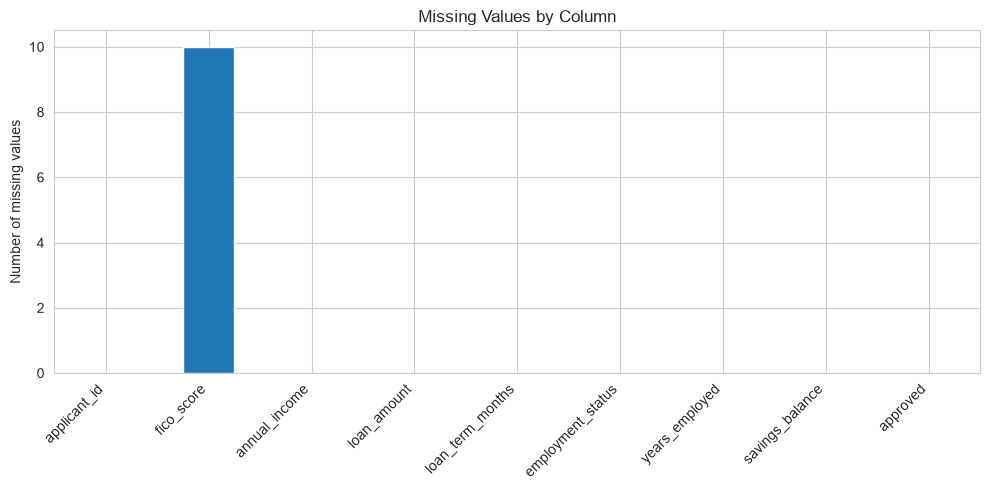

In [11]:
## TASK: Chart the missing values.
## Prompt Codex to draw a matplotlib bar chart of the number of missing (null) values in
## each column of df. Ask for a title ("Missing Values by Column"), a y-axis label, and the
## column names rotated so they are readable.

import matplotlib.pyplot as plt

df.isna().sum().plot(kind="bar", figsize=(10, 5))
plt.title("Missing Values by Column")
plt.ylabel("Number of missing values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Your Observations: Read the Raw Data (4 points)

Before we fix anything, write **five plain-English points** about what you have seen so far (Steps 1.1 to 1.5), in your own words. This is graded on whether your points are **true to the data**, not on fancy writing.

Ideas to comment on: how many applications there are, what one row represents, which columns are numbers and which are categories, what looks messy or wrong, and what the `approved` column is for.

*(Type your five points here.)*

1. The dataset has 232 rows and 9 columns. Each row represents one loan application.

2. The `approved` column records whether an application was approved or rejected in the past. That is the decision the model will later learn from.

3. The income, loan amount, and savings columns contain money values, but they were loaded as text. We’ll need to turn them into numbers before doing calculations.

4. Ten applications are missing a FICO score. The other columns have no missing values.

5. Some values look like data entry mistakes: one FICO score reaches 900, one loan term reaches 999 months, and one value for years employed reaches 150. We should deal with those before training a model.

## Cleaning: Fix the Four Problems, In Order

Your exploration turned up exactly four problems. We fix them in a **fixed order**, and it matters that you do the same four fixes the same way, so your cleaned data comes out right for the steps that follow.

1. **Money stored as text** -> turn into plain numbers.
2. **Duplicate applications** -> remove them.
3. **Impossible values** -> remove those rows.
4. **Missing FICO scores** -> fill them in.

### Fix 1 - Money stored as text

Some money values are written like `"$53,000"`. Python cannot do maths on text, so those columns were treated as text. We strip the `$` and the comma and turn them into real numbers.

In [ ]:
## TASK: Fix money stored as text.
## Three columns hold money as text like "$53,000": annual_income, loan_amount, savings_balance.
## Prompt Codex to remove the "$" and any commas from each of these three columns and convert
## them to numbers using pandas to_numeric (so anything odd becomes NaN). Then print the data
## types of just those three columns to confirm they are numeric now.

money_cols = ['annual_income', 'loan_amount', 'savings_balance']
______

### Fix 2 - Remove duplicate applications

Some rows are exact copies of another row. A duplicate would let the same application count twice and bias the model. We drop exact duplicates.

**Expected result:** 12 duplicates removed, **220 rows** remain.

In [ ]:
## TASK: Remove duplicate applications.
## Prompt Codex to: record how many rows there are now, drop exact duplicate rows and reset the
## index, then print how many duplicates were removed and how many rows remain.

______

### Fix 3 - Remove rows with impossible values

`describe()` showed values that cannot be real. These are data-entry errors, and we cannot know the true value, so we remove those few rows. Be careful: we remove rows where a value is **present but impossible**, not rows where FICO is simply blank (those are handled next).

**Expected result:** 8 rows removed, **212 rows** remain.

In [ ]:
## TASK: Remove rows with impossible values.
## Prompt Codex to remove rows from df where ANY of these is true:
##   fico_score > 850, annual_income < 0, loan_amount <= 0,
##   loan_term_months > 84, years_employed > 60, savings_balance < 0
## IMPORTANT: tell Codex NOT to remove rows just because fico_score is blank (NaN),
## only rows where a value is present but out of range.
## Then reset the index and print how many rows were removed and how many remain.

______

### Fix 4 - Fill in the missing FICO scores

A few applications have a blank FICO score. We will not drop them (that throws away good applications) and cannot leave them blank (the model needs a number). We fill each blank with the **median** FICO, a safe, standard choice.

**Expected result:** 10 blanks filled, **0 missing** afterwards.

In [ ]:
## TASK: Fill the missing FICO scores.
## Prompt Codex to: count how many fico_score values are missing, fill each missing value with
## the MEDIAN of the fico_score column, then print how many were filled and confirm 0 remain.

______

### Step 1.6 - Confirm the data is clean

One final check before we move on: the right number of rows, and not a single missing value anywhere.

**Expected result:** **212 rows**, 9 columns, and **0 missing values**.

In [ ]:
## TASK: Confirm the data is clean.
## Prompt Codex to print df.shape and the total number of missing values across the whole table.

______

# **Stage 2 - Business Insights**

The data is clean, so now we can trust what it tells us. In this stage we draw graphs and pull out plain facts about **who gets approved and why**. These pictures are how you will understand the business, and they are what you will lean on to answer the fairness questions at the end of this stage.

### Step 2.1 - How many were approved vs rejected?

The first question any lender asks: what share of applications get a yes? We count both outcomes and draw them as a bar chart.

**Expected result:** about **60% approved** (roughly 127 Approved, 85 Rejected).

In [ ]:
## TASK: Approved vs Rejected.
## Prompt Codex to, using df:
##   1. count how many rows are Approved and how many Rejected, and print the counts,
##   2. print the approval rate as a percentage,
##   3. draw a bar chart of the two counts (Approved green, Rejected red) with a title and y-axis label.

______

### Step 2.2 - What do the credit scores look like?

Beacon serves thin- and bruised-credit borrowers, so we expect a wide spread of FICO scores, not just high ones. Let's see the actual shape with a histogram.

**Expected result:** a spread across the whole range, with a clear chunk of applicants **below 660**, the borrowers the old flat rule would reject.

In [ ]:
## TASK: FICO distribution.
## Prompt Codex to draw a histogram of the fico_score column (about 20 bins) with a title and
## axis labels, and a vertical dashed line at 660 (the old flat-rule cut-off).

______

### Step 2.3 - Does approval depend on employment type?

Beacon exists partly to serve **self-employed** borrowers. If the data approved them at a very different rate from salaried applicants, that would be worth knowing.

In [ ]:
## TASK: Approval rate by employment type.
## Prompt Codex to, using df:
##   1. calculate the percentage of applications Approved within each employment_status, and print it,
##   2. draw a bar chart of those two approval rates with a title and a y-axis label ("Approval rate (%)").

______

### Step 2.4 - Do approved applicants just have higher scores?

If FICO alone decided everything, the old flat rule would have worked. Let's test that directly: compare the FICO scores of approved vs rejected applicants with a box plot. If the boxes overlap a lot, FICO alone is **not** enough.

**Expected result:** approved applicants score a little higher, **but the two boxes overlap heavily**, which is exactly why a one-number rule fails.

In [ ]:
## TASK: FICO by decision.
## Prompt Codex to draw a seaborn box plot of fico_score split by the approved column
## (Approved vs Rejected on the x-axis, fico_score on the y-axis), with a title and axis labels.

______

### Step 2.5 - Which numbers move together?

A correlation heatmap shows which columns rise and fall together. It helps you see that approval is linked to several columns at once, not just FICO.

**Expected result:** approval is positively linked with fico_score, income, and savings, no single column dominates.

In [ ]:
## TASK: Correlation heatmap.
## Prompt Codex to:
##   1. make a COPY of df and add a temporary numeric column approved_num (1 for Approved, 0 for Rejected),
##   2. select the numeric columns (fico_score, annual_income, loan_amount, loan_term_months,
##      years_employed, savings_balance, approved_num),
##   3. draw a seaborn heatmap of their correlations with the numbers annotated on each cell and a title.
## Do not change the original df permanently.

______

### Your EDA Findings (4 points)

Using the five graphs above, write **five findings** in your own words. Graded on whether they are true to what the graphs show.

*(Type your five findings here.)*

### Fairness Questions (10 points)

Answer these three questions in your own words. There is no code here, this is **your own thinking**, and the graphs above will help. Short answers are fine.

**Question 1 (3 points).** The model will use employment_status, years_employed, income, and savings, but not race or age. Do you think using these could still be unfair to some group of people? Answer **yes or no**, and give **one sentence of reasoning**.

*(Type your answer here.)*

---

**Question 2 (3 points).** The system only auto-decides when it is very confident (above 0.80 or below 0.20). Everything in between goes to a human officer. Why is that a good idea for a fair lender?

*(Type your answer here.)*

---

**Question 3 (4 points).** This model learns from what Beacon's officers decided in the past, not from who actually repaid their loans. What is one risk of building it that way?

*(Type your answer here.)*

# **Stage 3 - Model Training (6 Marks)**

Now we build the sorter itself. We will train one **logistic regression** model. It is a great fit here: it is simple to understand, and it naturally produces a **probability** for each application, which is exactly the confidence level our decision rule needs (the 0.20 and 0.80 cut-offs).

### Step 3.1 - Turn the decision into a number

Models work with numbers, not words. We turn the `approved` column into 1 (Approved) and 0 (Rejected). This new column is the **answer** the model will learn to predict.

In [ ]:
## TASK: Turn the decision into a number.
## Prompt Codex to create a new column in df called approved_flag that is 1 where approved is
## "Approved" and 0 otherwise, then show the count of each value.

______

### Step 3.2 - Choose the input columns (and leave out the dangerous ones)

Now we choose the columns the model may look at (the **features**) and separate the answer (the **target**).

Two columns must be left out, and knowing *why* is part of the lesson:
- **`applicant_id`** is just a label with no meaning.
- **`approved` / `approved_flag`** is the answer itself. Giving it to the model as an input would be **cheating** (this mistake is called "leakage").

In [ ]:
## TASK: Choose the input columns and the target.
## Prompt Codex to:
##   - build the input table X from these columns ONLY: fico_score, annual_income, loan_amount,
##     loan_term_months, years_employed, savings_balance
##   - add one more column to X called is_self_employed (1 when employment_status is
##     "Self-employed", else 0)
##   - build the target y from the approved_flag column
##   - NOT include applicant_id, approved, or approved_flag in X (that would be data leakage)
##   - print the shape of X
## Make sure X and y are the variable names, later steps use them.

X = ______
y = ______

### Step 3.3 - Split into training and test sets

We train on 80% of the data and hide 20% to test honestly. `stratify=y` keeps the same approve/reject balance in both halves, and `random_state=42` makes the split the same every time, so your results stay stable each time you run it.

**Expected result:** about **169 training rows** and **43 test rows**.

In [ ]:
## TASK: Split into training and test sets.
## Prompt Codex to split X and y using scikit-learn's train_test_split with
## test_size=0.2, stratify=y, and random_state=42. Name the outputs X_train, X_test,
## y_train, y_test, and print how many rows are in the training set and the test set.

X_train, X_test, y_train, y_test = ______

### Step 3.4 - Train the model

Now we train (the technical word is **fit**) the logistic regression on the training data. This is the moment the model learns the officers' pattern.

In [ ]:
## TASK: Train the model.
## Prompt Codex to create a scikit-learn LogisticRegression with max_iter=1000, fit it on
## X_train and y_train, and print a short confirmation message. Name the model `model`.

model = ______

### Step 3.5 - Which factors push toward approval?

A logistic regression is not a black box, we can read what it learned. Each feature gets a weight (a **coefficient**): positive pushes toward approval, negative pushes toward rejection.

In [ ]:
## TASK: Chart the model's feature weights.
## Prompt Codex to build a table pairing each feature name (X.columns) with its coefficient
## (model.coef_[0]), sort it, and draw a horizontal bar chart titled "What the Model Learned
## (Feature Weights)", green bars for positive weights and red for negative.

______

### Step 3.6 - Which parameter matters most, fairly compared

One catch with the chart above: `annual_income` is measured in tens of thousands and `years_employed` in single digits, so their raw weights are not directly comparable. To compare fairly, we put every column on the same scale first, then read the weights off a **separate** copy of the model. This does **not** change your main model or its accuracy.

**Expected result:** `annual_income` and `fico_score` come out as the strongest positive factors.

In [ ]:
## TASK: Fairly-compared feature importance (self-contained, does not touch the main model).
## Prompt Codex to:
##   1. import StandardScaler from sklearn.preprocessing,
##   2. fit a StandardScaler on X_train and make a SCALED COPY (do not overwrite X_train),
##   3. train a NEW, SEPARATE LogisticRegression(max_iter=1000) called importance_model on the
##      scaled copy and y_train,
##   4. pair each column of X_train with importance_model's coefficient, sort them,
##   5. draw a horizontal bar chart titled "Which Factors Matter Most (Fairly Compared)"
##      (green positive, red negative).
## Tell Codex NOT to change the original model or X_train/X_test.

______

# **Stage 4 - Evaluation (6 Marks)**

A model is only as good as its proof. We now measure the sorter with one honest number, **accuracy**, then do the two comparisons that matter to Beacon: is it better than the **old flat rule**, and how many files could it clear **without a human**?

### Step 4.1 - How accurate is the model?

Accuracy answers a simple question: of the 43 hidden test applications, what share did the model decide the same way the officers did?

**Expected result:** about **86%**.

In [ ]:
## TASK: Model accuracy.
## Prompt Codex to use the trained model to predict on X_test, compute the accuracy against
## y_test using accuracy_score, and print it as a percentage with one decimal place.
## Store the accuracy in a variable named `accuracy` (a later step reuses it).

accuracy = ______

### Step 4.2 - Beat the old flat rule (FICO >= 660)

Remember Beacon's failed shortcut: approve if FICO is 660 or higher. Let's measure how accurate that rule would be on the **same** test set, to prove the model is genuinely better.

**Expected result:** about **65%**, well below the model.

In [ ]:
## TASK: Flat-rule accuracy.
## Prompt Codex to predict on X_test with a simple rule (approve = 1 if fico_score >= 660,
## else reject = 0), then compute its accuracy against y_test and print it as a percentage.
## Store it in a variable named `flat_rule_accuracy` (a later step reuses it).

flat_rule_accuracy = ______

### Step 4.3 - Put all three side by side

The simplest possible "model" is to approve everyone. Since about 60% were approved, that is right about 60% of the time, the floor any real model must clear. Let's compute it and chart all three together.

**Expected result:** three bars, the model tallest at about 86%, the flat rule around 65%, the baseline around 60%.

In [ ]:
## TASK: Baseline + comparison chart.
## Prompt Codex to:
##   1. compute the accuracy of always predicting Approved (1) for every test row (the baseline),
##   2. draw a bar chart comparing three accuracies as percentages, the model (use the `accuracy`
##      variable), the flat rule (`flat_rule_accuracy`), and the always-approve baseline,
##      titled "Model vs Flat Rule vs Baseline", with each value written on top of its bar.

______

### Step 4.4 - How many files could clear without a human?

This ties the whole project back to Beacon's real goal: freeing up the five officers. Using the model's **confidence** (its approval probability), we sort the test applications into three piles: auto-approve (above 0.80), auto-reject (below 0.20), and send-to-human (in between).

**Expected result:** most files land in the two auto piles and clear instantly, only the genuinely borderline ones go to a human.

In [ ]:
## TASK: Sort applications by confidence.
## Prompt Codex to:
##   1. get the model's approval probability for each X_test row (probability of class 1) via predict_proba,
##   2. sort each application into three buckets: "Auto-approve" if probability > 0.80,
##      "Auto-reject" if < 0.20, and "Send to human" otherwise,
##   3. print how many test applications fall into each bucket,
##   4. draw a bar chart of the three bucket counts titled "How the Confidence Rule Sorts Applications".

______

### Your Conclusion

Put the three accuracies side by side and write, in your own words, **why the model beats the flat rule**. Think back to the box plot in Step 2.4 and the borrower Beacon exists to serve.

*(Write your conclusion here.)*

# **Submitting Your Work**

You have built a working loan sorter, start to finish, by directing an AI. To submit:

1. From the top menu, run the whole notebook one last time (**Run All**) and confirm every cell runs with no errors and every graph appears.
2. Check that **all five observation and answer cells** are filled in with your own words: the two "Your Observations / Findings" cells, the three fairness questions, and your final conclusion.
3. Export the notebook to a single **HTML file** (File -> Export / Save as -> HTML).
4. Submit that one HTML file, together with your **full Codex prompt trail** (starting with your Stage 0 planning prompt).

Well done.